In [110]:
import pandas as pd 
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

In [111]:
class WindowDataset(Dataset):
    def __init__(self, _data, _window):
        # _data : tensor, array 1차원 데이터 형태
        # _window : 구간의 크기 
        self.data = _data
        self.window = _window
        # DataLoader에서 사용이 가능한 인덱스의 최대 값
        self.n = len(_data) - _window

    def __len__(self):
        return self.n
    
    def __getitem__(self, idx):
        # idx : 0 ~ self.n-1 사이의 정수가 대입 (DataLoader에서 자동으로 대입)
        x = self.data[idx:idx + self.window]
        y = self.data[idx + self.window]
        return x, y
    

In [112]:
# RNN 모델 정의 
class RNNModel(nn.Module):
    def __init__(self,
                 input_size, 
                 hidden_size = 64, 
                 num_layers = 1, 
                 dropout = 0.0, 
                 nonlinearity = 'tanh', 
                 bidirectional = False):
        super(RNNModel, self).__init__()
        # super().__init__()
        self.rnn = nn.RNN(
            input_size = input_size,
            hidden_size = hidden_size, 
            num_layers = num_layers, 
            dropout = dropout, 
            nonlinearity = nonlinearity, 
            bidirectional = bidirectional, 
            # batch_first는 기본이 Fasle였던걸 까먹고 안 넣고 있었네요 
            # 죄송합니다. 
            # batch_first가 False인 경우, 입력 데이터(구간의 개수, 배치크기, 입력 데이터 피쳐의 수)
            # (배치 크기, 구간의 크기, 입력 피쳐의 개수) --> True로 변경 
            batch_first = True
        )

        # output_feature가 역방향을 포함한다면 2배로 늘어난다. 
        if bidirectional:
            hidden_size *= 2
        print(f"hidden_size : {hidden_size}")
        self.model = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, h_n = self.rnn(x)
        last_hidden = h_n[-1]
        result = self.model(last_hidden)
        return result

In [113]:
# 모델 학습 시 검증 데이터를 이용하여 모델의 성능을 평가 할수 있도록 검증 데이터 평가 함수 

@torch.no_grad()
def evaluate_mse(dataloader, model):
    # dataloader -> 검증 데이터셋의 dataloader
    model.eval()
    total_loss = 0
    total_n = 0
    for x, y in dataloader:
        x = x.float()
        y = y.float()
        pred = model(x)
        loss = nn.MSELoss()(pred, y)
        # total_loss에서도 +=을 +로만 쓰는 막대한 실수를 했네요 
        total_loss += loss.item() * x.size(0)
        total_n += x.size(0)
    return total_loss / max(total_n, 1)

In [114]:
df = pd.read_csv("../csv/aapl.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9715 entries, 0 to 9714
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9715 non-null   object 
 1   Open       9714 non-null   float64
 2   High       9714 non-null   float64
 3   Low        9714 non-null   float64
 4   Close      9714 non-null   float64
 5   Adj Close  9714 non-null   float64
 6   Volume     9713 non-null   float64
dtypes: float64(6), object(1)
memory usage: 531.4+ KB


In [115]:
df.dropna(inplace=True)

In [116]:
# 수정종가, 날짜 데이터만 추출
df = df[['Date', 'Adj Close']]

In [117]:
values = df[['Adj Close']].values
values

array([[  0.410525],
       [  0.389106],
       [  0.360548],
       ...,
       [199.460007],
       [198.779999],
       [199.169998]], shape=(9713, 1))

In [118]:
df['Adj Close'].values.reshape(-1, 1)

array([[  0.410525],
       [  0.389106],
       [  0.360548],
       ...,
       [199.460007],
       [198.779999],
       [199.169998]], shape=(9713, 1))

In [119]:
# 75:25 비율로 학습, 검증 데이터로 분할
split_idx = int(len(values) * 0.75)
split_idx

7284

In [120]:
train_data = values[:split_idx]
test_data = values[split_idx:]

In [121]:
# MinMaxScaler로 데이터 정규화
scaler = MinMaxScaler()
train_sc = scaler.fit_transform(train_data)
test_sc = scaler.transform(test_data)

In [122]:
test_sc

array([[0.93723805],
       [0.956606  ],
       [0.91811525],
       ...,
       [7.80873011],
       [7.78208726],
       [7.7973675 ]], shape=(2429, 1))

In [123]:
# 스케일링이 완료된 데이터를 Tensor로 변환 
train_sc = torch.tensor(train_sc, dtype=torch.float32)
test_sc = torch.tensor(test_sc, dtype=torch.float32)

In [124]:
# WindowDataset에 데이터를 대입 
train_ds = WindowDataset(train_sc, _window=60)
test_ds = WindowDataset(test_sc, _window=60)

In [125]:
# Dataset를 DataLoader로 생성 
train_dl = DataLoader(train_ds, batch_size=128, shuffle = True, drop_last = True)
test_dl = DataLoader(test_ds, batch_size=256, shuffle=False, drop_last = False)

In [126]:
aapl_model = RNNModel(
    input_size = 1, 
    hidden_size = 128
)
criterion = nn.MSELoss()
optimizer = optim.Adam(aapl_model.parameters(), lr = 0.001)

hidden_size : 128


In [127]:
# 모델 학습 
train_history, test_history = [], []
for epoch in range(20):
    aapl_model.train()
    running, n_seen = 0.0, 0
    for x, y in train_dl:
        x = x.float()
        y = y.float()
        pred = aapl_model(x)
        loss = criterion(pred, y)
        # print(x.shape, y.shape)
        # print(pred.shape, y.shape)
        # break
        optimizer.zero_grad()
        loss.backward()
        # 가중치 발산 방지 
        nn.utils.clip_grad_norm_(aapl_model.parameters(), 1.0)
        optimizer.step()

        running += loss.item() * y.size(0)
        n_seen += y.size(0)
    train_mse = running / n_seen
    test_mse = evaluate_mse(test_dl, aapl_model)
    train_history.append(train_mse)
    test_history.append(test_mse)
    print(f"Epoch {epoch+1} Train MSE: {round(train_mse, 8)} Test MSE: {round(test_mse, 8)}")

Epoch 1 Train MSE: 0.00955066 Test MSE: 4.74565239
Epoch 2 Train MSE: 0.0001147 Test MSE: 4.62844465
Epoch 3 Train MSE: 9.423e-05 Test MSE: 4.43865355
Epoch 4 Train MSE: 8.758e-05 Test MSE: 4.28467715
Epoch 5 Train MSE: 9.183e-05 Test MSE: 4.11001912
Epoch 6 Train MSE: 9.055e-05 Test MSE: 4.05638002
Epoch 7 Train MSE: 9.142e-05 Test MSE: 3.89873675
Epoch 8 Train MSE: 0.00010145 Test MSE: 3.7782075
Epoch 9 Train MSE: 8.678e-05 Test MSE: 3.65182151
Epoch 10 Train MSE: 9.922e-05 Test MSE: 3.5539553
Epoch 11 Train MSE: 9.565e-05 Test MSE: 3.45941913
Epoch 12 Train MSE: 8.414e-05 Test MSE: 3.42640114
Epoch 13 Train MSE: 9.833e-05 Test MSE: 3.31220313
Epoch 14 Train MSE: 8.579e-05 Test MSE: 3.25320631
Epoch 15 Train MSE: 0.00010112 Test MSE: 3.15096165
Epoch 16 Train MSE: 9.944e-05 Test MSE: 3.06890779
Epoch 17 Train MSE: 8.711e-05 Test MSE: 3.0099516
Epoch 18 Train MSE: 8.684e-05 Test MSE: 2.91853221
Epoch 19 Train MSE: 8.16e-05 Test MSE: 2.83802767
Epoch 20 Train MSE: 7.632e-05 Test MSE: 2

In [128]:
# 학습 된 모델을 이용하여 예측 값을 확인하고 실젯값과의 차이를 그래프로 시각화
aapl_model.eval()

preds = []
trues = []

with torch.no_grad():
    for x, y in test_dl:
        x = x.float()
        y = y.float()

        pred = aapl_model(x)
        preds.append(pred.cpu())
        trues.append(y.cpu())


In [129]:
len(preds[0])

256

In [130]:
# cat() : 여러개의 텐서를 하나의 텐서로 결합
# squeeze() : 텐서의 차원 중 크기가 1인 차원을 제거
# numpy() : 텐서 타입을 numpy의 array 타입으로 전환
preds = torch.cat(preds, dim=0).squeeze(-1).numpy()
trues = torch.cat(trues, dim=0).squeeze(-1).numpy()

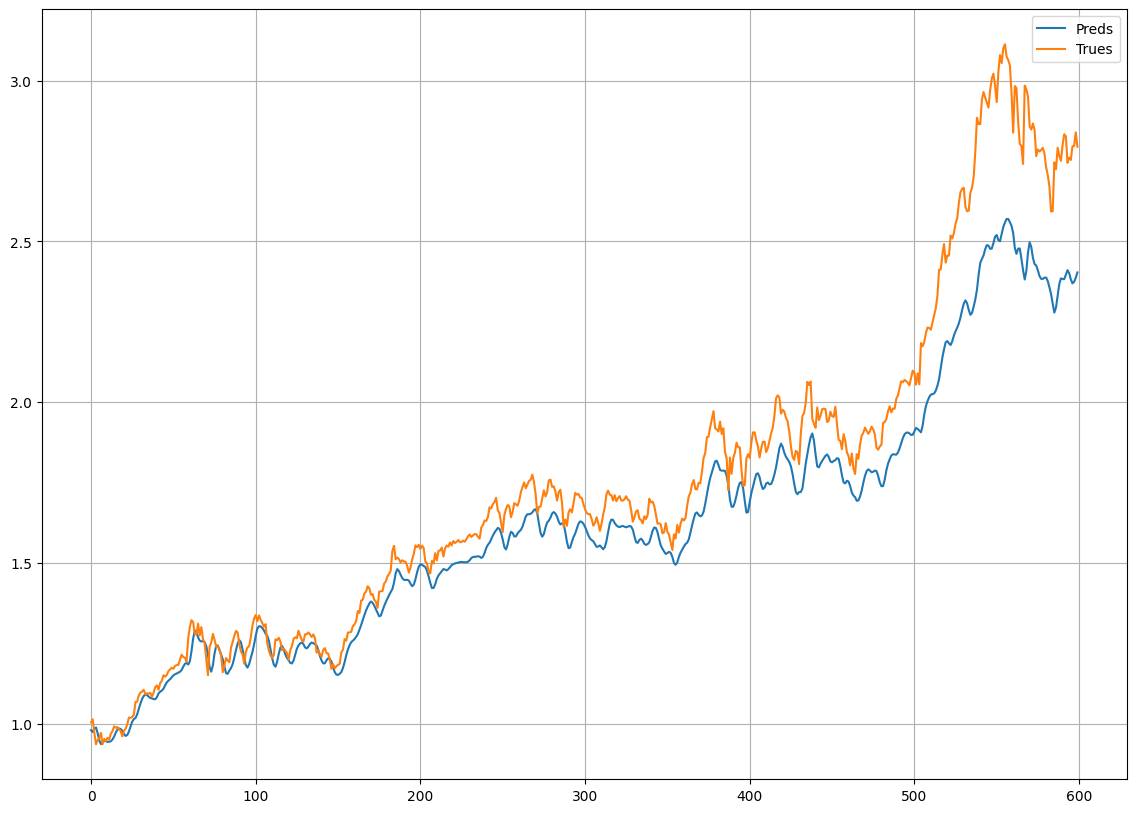

In [131]:
plt.figure(figsize = (14, 10))
plt.plot(preds[:600], label = 'Preds')
plt.plot(trues[:600], label = 'Trues')
plt.legend()
plt.grid()
plt.show()

In [132]:
# 스케일링 데이터를 원본의 데이터셋으로 변환 -> 그래프로 시각화
pred_origin = scaler.inverse_transform(preds.reshape(-1, 1)).squeeze(-1)
pred_origin

array([25.153872, 25.010748, 25.275745, ..., 99.366936, 99.49345 ,
       99.5345  ], shape=(2369,), dtype=float32)

In [133]:
true_origin = scaler.inverse_transform(trues.reshape(-1, 1)).squeeze(-1)

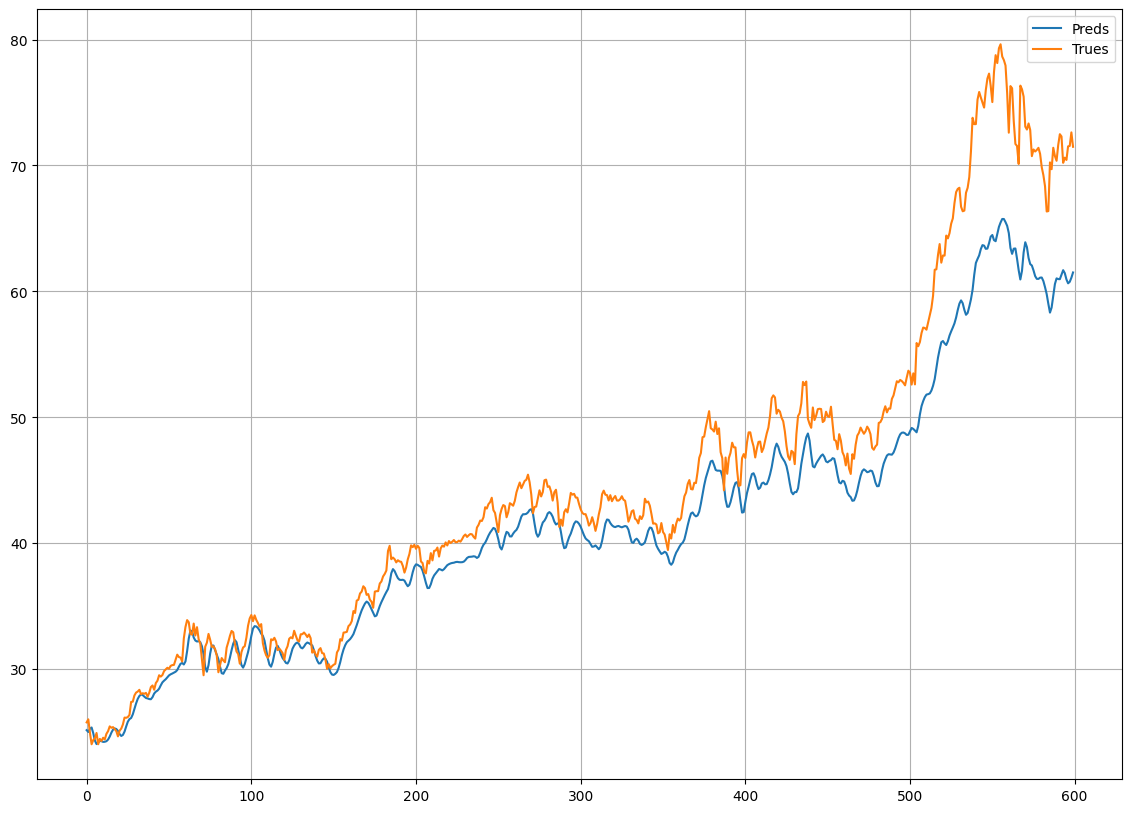

In [134]:
plt.figure(figsize=(14, 10))
plt.plot(pred_origin[:600], label = 'Preds')
plt.plot(true_origin[:600], label = 'Trues')
plt.legend()
plt.grid()
plt.show()

In [135]:
# 피쳐의 개수를 증가 모델에 학습 ( 종가, 거래량 )
df = pd.read_csv("../csv/aapl.csv")
# 결측치 제거 
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9713 entries, 0 to 9714
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9713 non-null   object 
 1   Open       9713 non-null   float64
 2   High       9713 non-null   float64
 3   Low        9713 non-null   float64
 4   Close      9713 non-null   float64
 5   Adj Close  9713 non-null   float64
 6   Volume     9713 non-null   float64
dtypes: float64(6), object(1)
memory usage: 607.1+ KB


In [136]:
# 학습 데이터 
x = df[['Adj Close', 'Volume']].astype(float).values
y = df[['Adj Close']].astype(float).values

In [137]:
# Scaler를 2개 생성 
scaler_x = StandardScaler()
scaler_y = StandardScaler()

# 데이터 80:20 비율로 데이터 분할 
split_idx = int(len(x)*0.8)
X_train, X_test = x[ : split_idx], x[split_idx : ]
y_train, y_test = y[ : split_idx], y[split_idx : ]

# 스케일링 
X_train_sc = scaler_x.fit_transform(X_train)
X_test_sc = scaler_x.transform(X_test)

y_train_sc = scaler_y.fit_transform(y_train)
y_test_sc = scaler_y.transform(y_test)

In [138]:
type(X_train_sc)

numpy.ndarray

In [139]:
class windowDS(Dataset):
    def __init__(self, _x, _y, _window):
        self.x = _x
        self.y = _y
        self.window = _window
        # 최대 인덱스의 값 
        self.n = len(_x) - _window

    # 데이터의 길이를 보여주는 함수 
    def __len__(self):
        return self.n
    
    # 데이터로더가 실제 데이터를 가져가는 함수 
    def __getitem__(self, idx):
        x = self.x[idx : idx + self.window]
        y = self.y[idx + self.window]
        # 현재 x, y는 array 형태 이기때문에 torch에서 사용이 불가능 
        # tensor 형태로 변환
        # tonsor() : 2차원 데이터를 tensor 형태로 변환 ( 깊은 복사 )
        # from_numpy() : array 형태의 데이터를 tensor 형태로 변환 ( 얕은 복사 )
        x_tensor = torch.from_numpy(x).float()
        y_tensor = torch.from_numpy(y).float()
        return x_tensor, y_tensor

In [140]:
# RNN 모델 정의 
class RNNModel(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size = 64, 
            num_layers = 1, 
            nonlinearity = 'tanh', 
            dropout = 0.0, 
            bidirectional = False, 
            batch_first = True
    ):
        super(RNNModel, self).__init__()
        # bidirectional이 True인 경우, hidden_size가 2배로 늘려준다. 
        hidden_size = hidden_size * (2 if bidirectional else 1)
        self.rnn = nn.RNN(
            input_size = input_size, 
            hidden_size = hidden_size, 
            num_layers = num_layers, 
            nonlinearity = nonlinearity, 
            dropout = dropout, 
            bidirectional = bidirectional, 
            batch_first = batch_first
        )
        # 비선형 모델 학습 -> 선형 -> 비선형 활성화 함수 추가 (다층 퍼셉트론 구조)
        self.model = nn.Sequential(
            nn.Linear(hidden_size, hidden_size * 2), 
            nn.ReLU(),     
            nn.Linear(hidden_size * 2, 1)
        )
    # 순전파 함수 정의 
    def forward(self, x):
        out, h_n = self.rnn(x)
        last_hidden = h_n[-1]
        result = self.model(last_hidden)
        return result

In [141]:
# 구간별 데이터셋을 구성 
train_ds = windowDS(X_train_sc, y_train_sc, _window=60)
test_ds = windowDS(X_test_sc, y_test_sc, _window=60)
# 데이터 로더 생성 
train_dl = DataLoader(train_ds, shuffle=True, drop_last=True, batch_size = 64)
test_dl = DataLoader(test_ds, shuffle = False, drop_last=False, batch_size=128)

In [142]:
# 모델 생성 
aapl_model = RNNModel(input_size=2, hidden_size=128)
# 손실 함수 
criterion = nn.MSELoss()
# 옵티마이저 설정 
optimizer = optim.Adam(aapl_model.parameters(), lr = 0.001)

In [143]:
# 평가 함수 생성( 반복 학습을 하면서 검증 데이터셋을 이용한 Loss 확인 함수 )

# 데코레이터 생성 
@torch.no_grad()
def evaluate_mse(dl):
    # 모델 평가모드 전환
    aapl_model.eval()
    # 전체 로스의 값, 전체 데이터의 개수 초기 값 설정
    total_loss, total_n = 0.0, 0

    for x, y in dl:
        x = x.float()
        y = y.float()
        pred = aapl_model(x)
        loss = criterion(pred, y)
        total_loss += loss.item() * y.size(0)
        total_n += y.size(0)
    return total_loss / max(total_n, 1)

# 로스의 변화량을 확인하기 위해 빈 리스트를 생성 (반복 학습에 따른 loss의 변화를 그래프로 시각화 하기 위해)
train_histroty, test_history = [], []
# 반복 횟수 epochs -> 구지 range함수에 넣지 않고 변수로 반복 횟수를 설정하는 이유는? 함수화 할때 매개변수로 사용
epochs = 20
for epoch in range(epochs):
    # 학습 모드로 전환
    aapl_model.train()
    # loss의 합계, 데이터의 개수 
    total_loss, total_n = 0.0, 0

    for x, y in train_dl:
        x = x.float()
        y = y.float()

        pred = aapl_model(x)
        loss = criterion(pred, y)
        # 기울기 초기화
        optimizer.zero_grad()
        # 자동 미분(역전파)
        loss.backward()
        # 기울기 폭발 방지
        nn.utils.clip_grad_norm_(aapl_model.parameters(), 1.0)
        # 기울기를 변화
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        total_n += y.size(0)
    
    # 학습 데이터 전체의 loss을 구한다. 
    train_mse = total_loss / max(total_n, 1)
    val_mse = evaluate_mse(test_dl)
    train_history.append(train_mse)
    test_history.append(val_mse)
    print(f"Epoch : {epoch + 1} , train_mse : {round(train_mse, 4)}, test_mse : {round(val_mse, 4)}")



Epoch : 1 , train_mse : 0.0559, test_mse : 31.2384
Epoch : 2 , train_mse : 0.0014, test_mse : 29.2791
Epoch : 3 , train_mse : 0.0011, test_mse : 28.2779
Epoch : 4 , train_mse : 0.0012, test_mse : 26.5379
Epoch : 5 , train_mse : 0.0014, test_mse : 23.6376
Epoch : 6 , train_mse : 0.0013, test_mse : 23.7013
Epoch : 7 , train_mse : 0.0008, test_mse : 21.9068
Epoch : 8 , train_mse : 0.0009, test_mse : 21.2928
Epoch : 9 , train_mse : 0.0012, test_mse : 20.0832
Epoch : 10 , train_mse : 0.0009, test_mse : 20.2952
Epoch : 11 , train_mse : 0.0015, test_mse : 16.7315
Epoch : 12 , train_mse : 0.0007, test_mse : 16.1499
Epoch : 13 , train_mse : 0.0007, test_mse : 16.3301
Epoch : 14 , train_mse : 0.0009, test_mse : 16.2723
Epoch : 15 , train_mse : 0.0008, test_mse : 15.1168
Epoch : 16 , train_mse : 0.0008, test_mse : 14.8948
Epoch : 17 , train_mse : 0.0008, test_mse : 14.7959
Epoch : 18 , train_mse : 0.0011, test_mse : 13.5744
Epoch : 19 , train_mse : 0.0008, test_mse : 14.3445
Epoch : 20 , train_ms

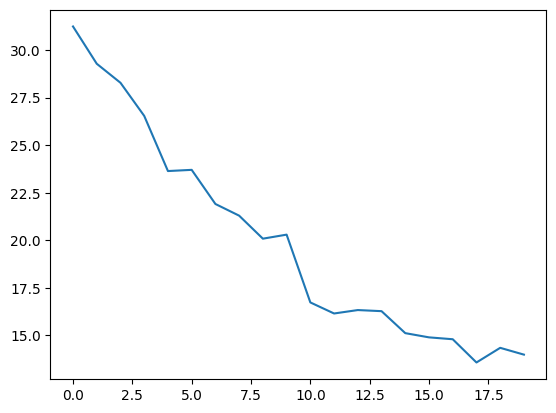

In [144]:
# mse의 값들의 변화
plt.plot(test_history)
plt.show()


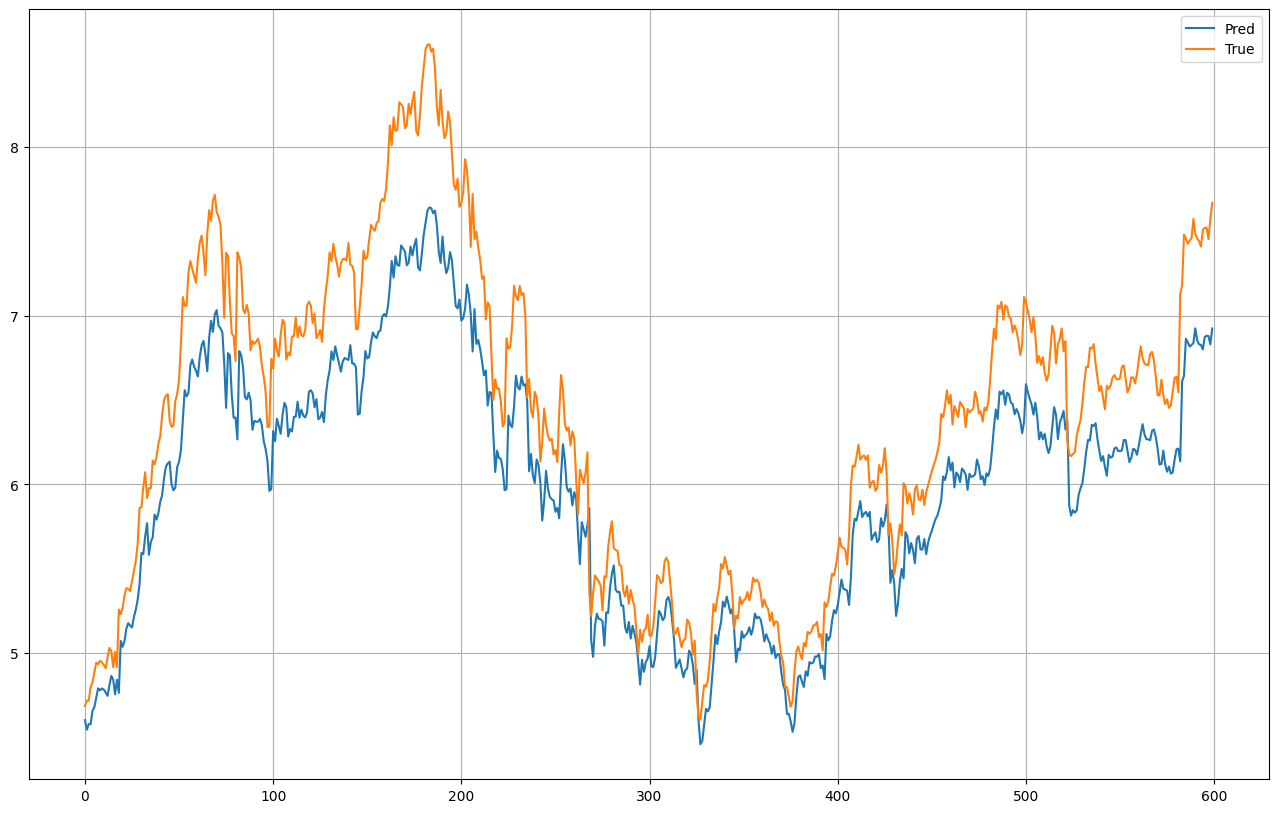

In [145]:
# 검증 데이터를 이용하여 예측 값을 생성하고 그래프 시각화 
aapl_model.eval()

preds, trues = [], []

with torch.no_grad():
    for x, y in test_dl:
        x = x.float()
        y = y.float()
        pred = aapl_model(x)

        preds.append(pred.cpu())
        trues.append(y.cpu())

preds = torch.cat(preds, dim=0).squeeze(-1).numpy()
trues = torch.cat(trues, dim=0).squeeze(-1).numpy()

plt.figure(figsize=(16, 10))
plt.plot(preds[:600], label = 'Pred')
plt.plot(trues[:600], label = 'True')
plt.legend()
plt.grid()
plt.show()
